In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# We will use the Seaborn library
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/telecom_churn.csv")

In [4]:
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [5]:
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

In [10]:
df['Churn'] = df['Churn'].astype('int')

array([[<Axes: title={'center': 'Account length'}>,
        <Axes: title={'center': 'Area code'}>,
        <Axes: title={'center': 'International plan'}>,
        <Axes: title={'center': 'Voice mail plan'}>],
       [<Axes: title={'center': 'Number vmail messages'}>,
        <Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total day calls'}>,
        <Axes: title={'center': 'Total day charge'}>],
       [<Axes: title={'center': 'Total eve minutes'}>,
        <Axes: title={'center': 'Total eve calls'}>,
        <Axes: title={'center': 'Total eve charge'}>,
        <Axes: title={'center': 'Total night minutes'}>],
       [<Axes: title={'center': 'Total night calls'}>,
        <Axes: title={'center': 'Total night charge'}>,
        <Axes: title={'center': 'Total intl minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>],
       [<Axes: title={'center': 'Total intl charge'}>,
        <Axes: title={'center': 'Customer service calls'}>,
        <Axe

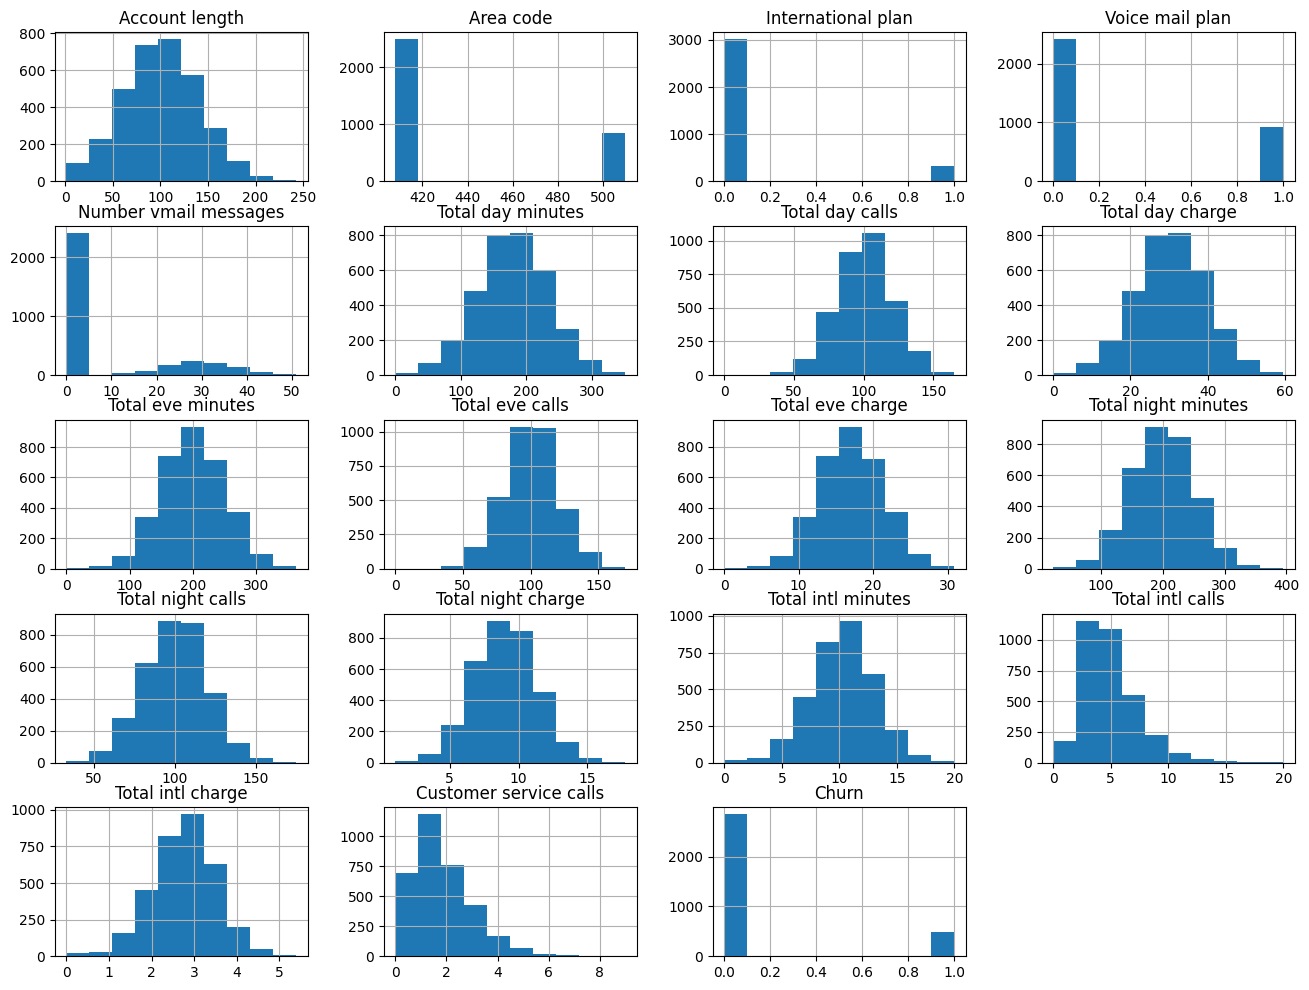

In [11]:
plt.rcParams['figure.figsize'] = (16, 12)
df.drop(['State'], axis=1).hist()

<Axes: >

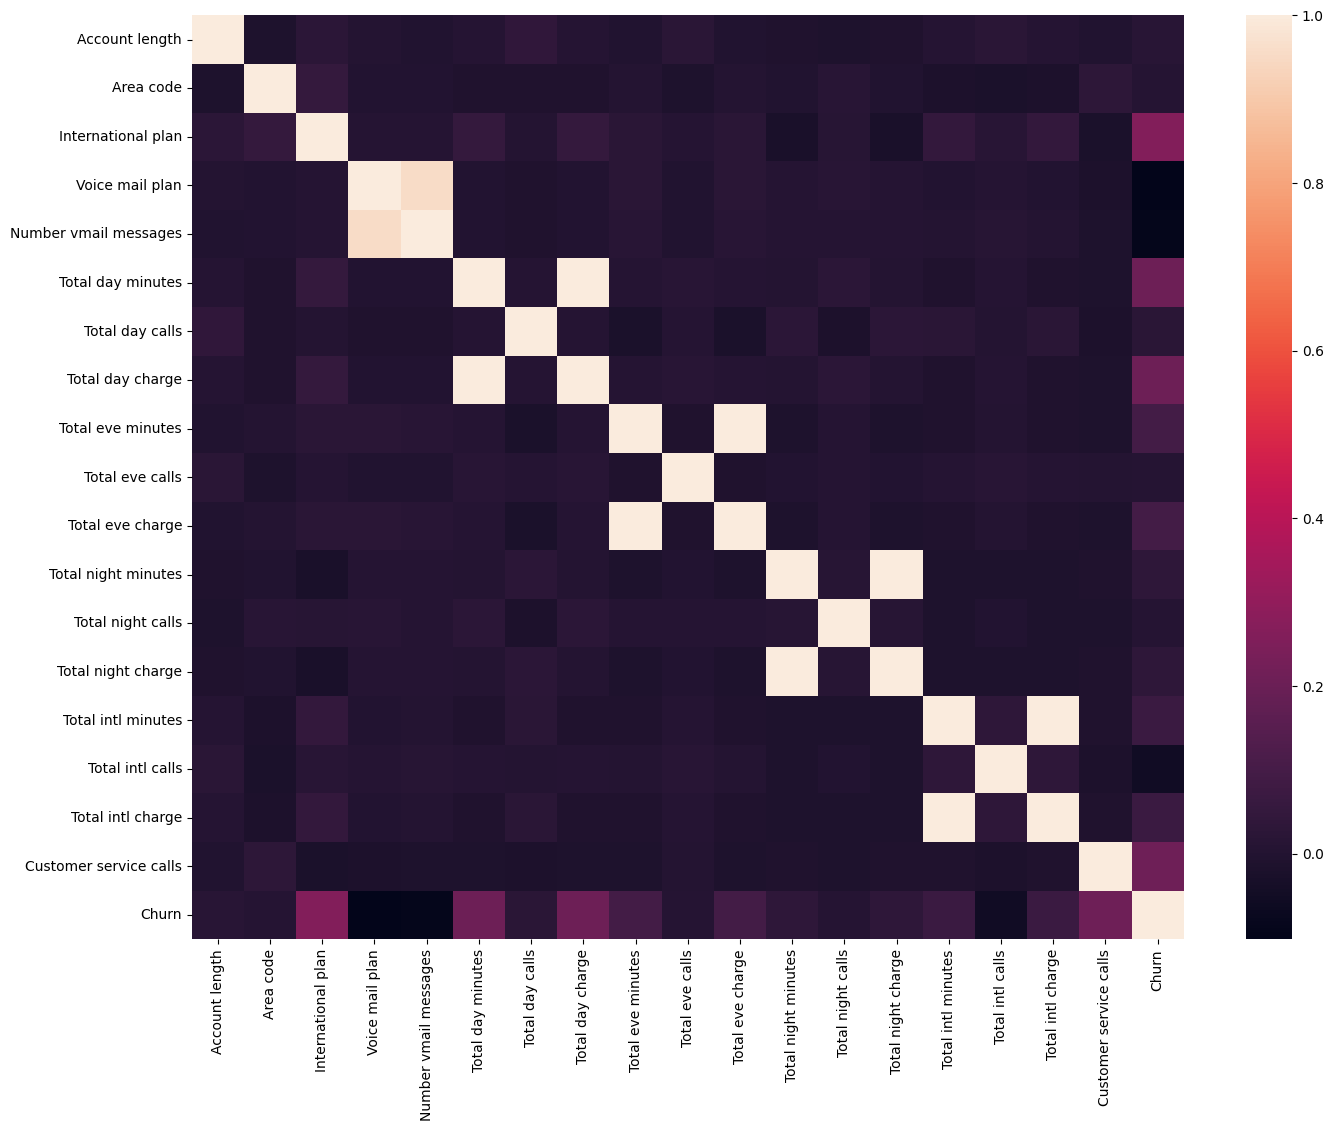

In [13]:
sns.heatmap(df.drop(['State'], axis=1).corr())

In [14]:
df.drop(['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge'], axis=1, inplace=True)

In [15]:
df.shape

(3333, 16)

In [16]:
df['Total day minutes'].describe()

count    3333.000000
mean      179.775098
std        54.467389
min         0.000000
25%       143.700000
50%       179.400000
75%       216.400000
max       350.800000
Name: Total day minutes, dtype: float64

<Axes: xlabel='Total day minutes'>

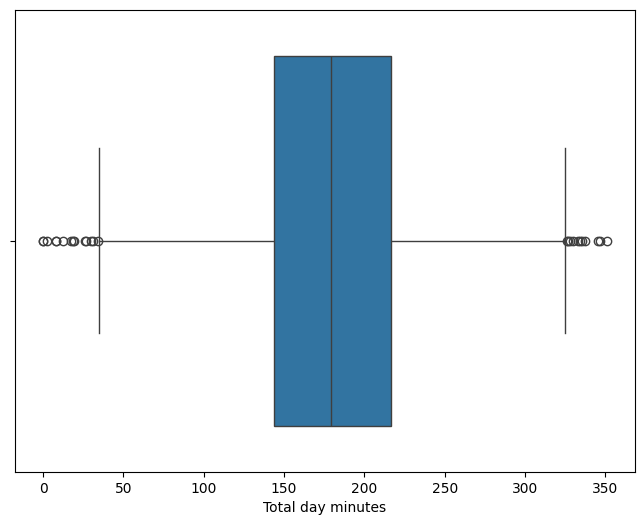

In [18]:
plt.rcParams['figure.figsize'] = (8, 6)
sns.boxplot(x='Total day minutes', data=df)

<Axes: >

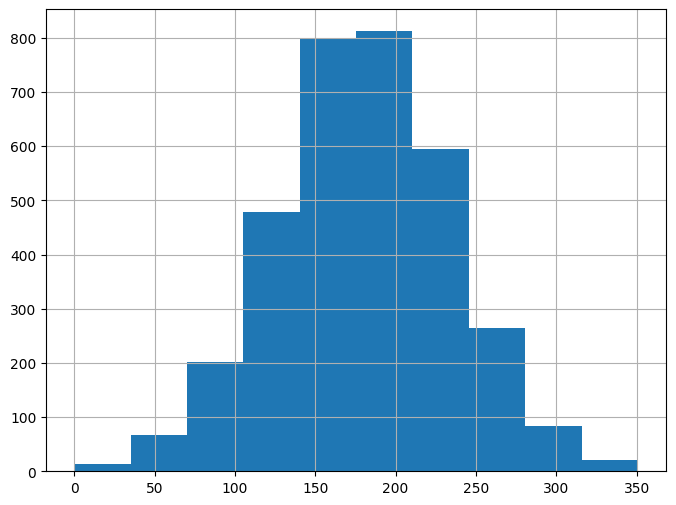

In [19]:
plt.rcParams['figure.figsize'] = (8, 6)
df['Total day minutes'].hist()

In [21]:
df['State'].value_counts().head()

State
WV    106
MN     84
NY     83
AL     80
OH     78
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

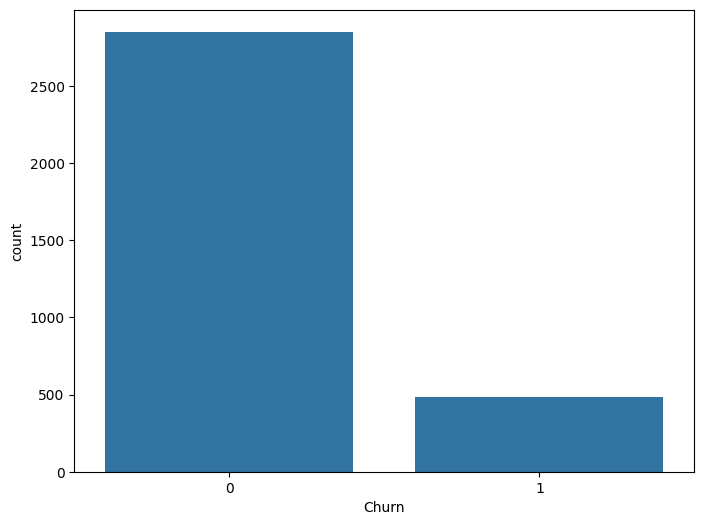

In [22]:
sns.countplot(x='Churn', data=df)

# Interactions num-num

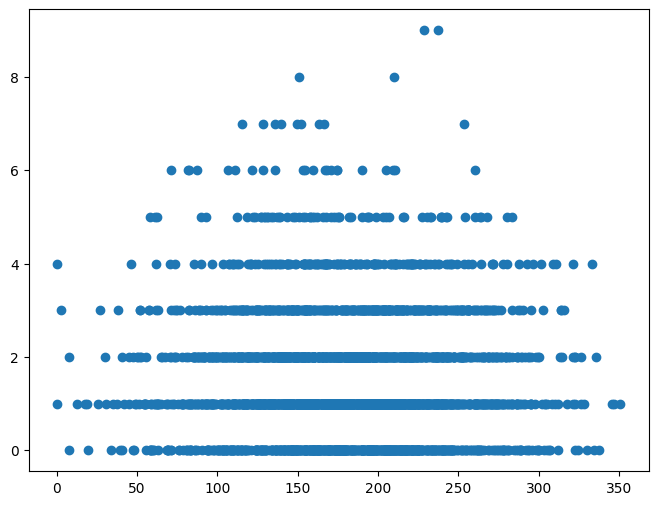

In [25]:
plt.scatter(df['Total day minutes'], df['Customer service calls'])

<Axes: >

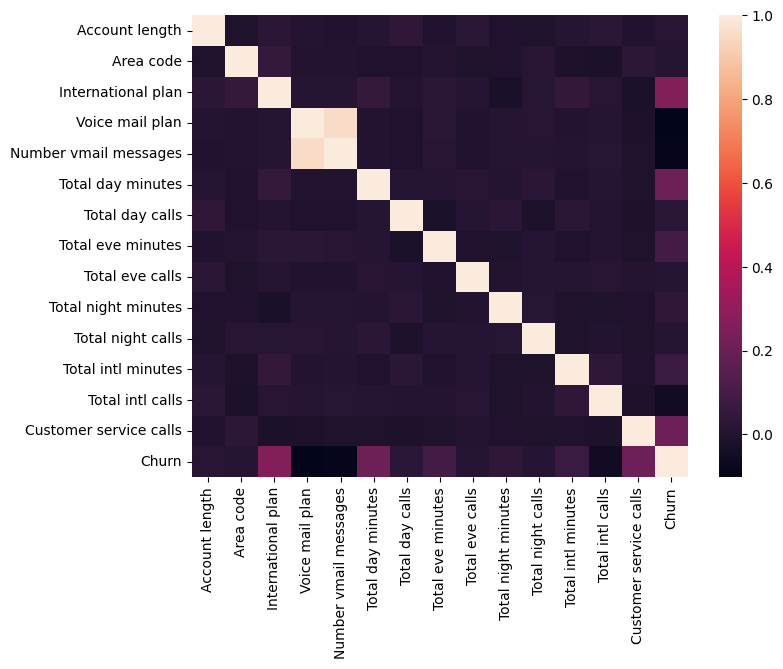

In [29]:
sns.heatmap(df.drop(['State'], axis=1).corr())

# Interactions cat-cat

In [30]:
pd.crosstab(df['Churn'], df['Customer service calls'])

Customer service calls,0,1,2,3,4,5,6,7,8,9
Churn,,,,,,,,,,
0,605,1059,672,385,90,26,8,4,1,0
1,92,122,87,44,76,40,14,5,1,2


<Axes: xlabel='Customer service calls', ylabel='count'>

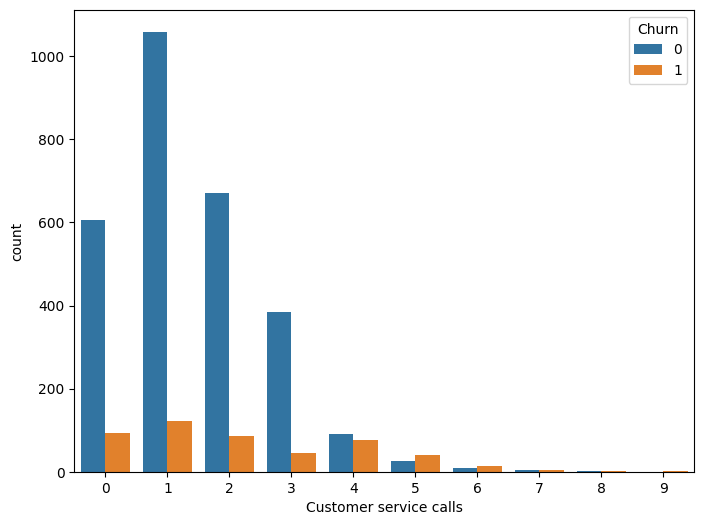

In [31]:
sns.countplot(x='Customer service calls', hue='Churn', data=df)

<Axes: xlabel='State', ylabel='count'>

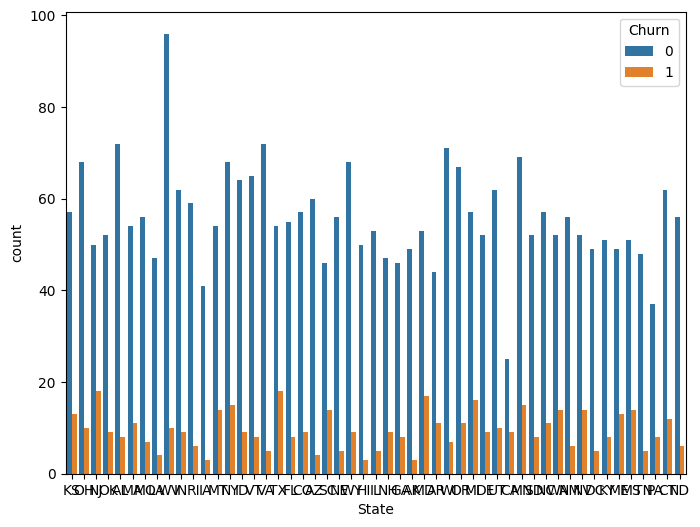

In [33]:
sns.countplot(x=df['State'], hue=df['Churn'], data=df)

<Axes: xlabel='Churn', ylabel='Total day minutes'>

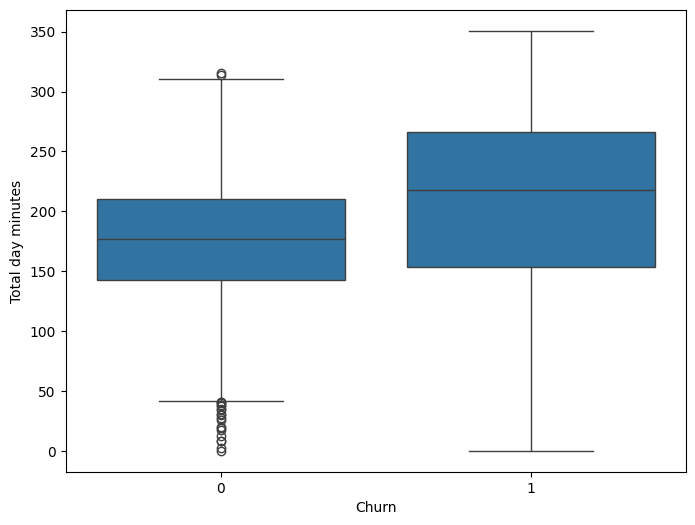

In [34]:
sns.boxplot(x=df['Churn'], y=df['Total day minutes'], data=df)